# CLV Rooftop Solar PV — Technical & Economic Feasibility

Simulation of a rooftop solar PV system for **Columbia Lake Village (CLV)**, University of Waterloo.

**Data sources**
1. *Eric D. Soulis Weather Station* — hourly on-campus irradiance/temperature/wind (2015–2024)
2. *Electricity Consumption Monthly* — CLV monthly kWh (2015–2024)
3. *Google Solar API* — measured roof geometry for 269 CLV buildings (12 m probe sweep) (`solar_api_responses/_summary.json`)

**Method**: PV yield is modelled per kW with **pvlib** (Erbs decomposition → plane-of-array transposition →
PVWatts with cell-temperature model), using only weather years with complete solar data. System size comes
from the Google Solar API roof measurements. Yield is cross-checked against Google's independent estimate.

**Known data pitfalls handled below**
- Weather sentinels are inconsistent (−999.9, −9999.9004, …) → any negative irradiance is treated as invalid
- 2019 & 2022 station datalogger outages (69% / 77% missing) → excluded; we use 2020, 2023, 2024
- COVID suppressed campus load Mar 2020 – late 2021 → excluded from the demand baseline

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib

DATA = Path("Sustainable_Energy_Systems/data")
API_SUMMARY = Path("solar_api_responses/_summary.json")

# Site (CLV) and array geometry
LAT, LON, TZ = 43.4703, -80.5625, "America/Toronto"  # station clock follows DST (verified: solar noon shifts ~1 h in summer)
TILT, AZIMUTH = 35, 180                          # SAM guide: latitude-optimised tilt, due south

# Chart style — light surface, recessive chrome (palette validated for CVD safety)
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, AQUA, YELLOW, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.figsize": (12, 4.5), "figure.dpi": 110,
})

## 1. Weather data — load and clean

The station encodes missing data with several different sentinels (−999.9, −9999.9004, −2499.2, …),
so filtering only −999.9 silently corrupts aggregates. Rule: **any negative irradiance is invalid**;
for temperature/wind, anything below −100 is a sentinel.

In [2]:
weather = pd.read_csv(DATA / "Eric D. Soulis Weather Station.csv")
weather.index = pd.to_datetime(weather[["Year", "Month", "Day", "Hour"]]).dt.tz_localize(
    TZ, nonexistent="shift_forward", ambiguous="NaT")
weather = weather[weather.index.notna()]

w = pd.DataFrame(index=weather.index)
w["ghi"] = weather["Solar - Incoming"].where(weather["Solar - Incoming"] >= 0)
w["temp_air"] = weather["Temperature"].where(weather["Temperature"] > -100)
w["wind_speed"] = weather["Wind Speed - Average 2.0"].where(weather["Wind Speed - Average 2.0"] >= 0)

# Interpolate only short gaps (<=3 h); long outages stay NaN and disqualify the year
w = w.interpolate(limit=3)

valid_by_year = w["ghi"].notna().groupby(w.index.year).mean()
GOOD_YEARS = [y for y, frac in valid_by_year.items() if frac > 0.98]
print("solar data completeness by year:")
print((valid_by_year * 100).round(1).astype(str) + " %")
print(f"\nyears used for simulation: {GOOD_YEARS}")

solar data completeness by year:
2015     96.9 %
2016    100.0 %
2017     96.4 %
2018     95.4 %
2019     31.1 %
2020    100.0 %
2021     99.5 %
2022     23.3 %
2023     99.7 %
2024     99.2 %
Name: ghi, dtype: str

years used for simulation: [2016, 2020, 2021, 2023, 2024]


## 2. CLV electricity demand — choosing an honest baseline

Two anomalies shape the choice:
- **Billing cadence**: CLV was billed *bimonthly* until Feb 2017 (blank alternate months, two months
  per reading) — readings are normalized to per-month rates using the record's Start/End dates.
- **COVID** suppressed load Mar 2020 – late 2021 (campus emptied) — excluded.
- **2024 is anomalous**: consumption fell ~40% vs 2023 — down in *every* month (Jan −25%, Feb −38%)
  and near-empty May–Sep (−80% at the trough), partially recovering by December. The pattern suggests
  progressive vacancy with a summer shutdown, not a metering fault (no other building shows it).
  Investigated: UW housing pages (live + 2024 archive snapshots) show no closure notice, and the
  challenge organizers, asked directly, could not confirm the cause. Treated as an unexplained
  occupancy anomaly and excluded from the baseline.

Baseline = **2022–2023**, the most recent fully-occupied post-COVID years. The offset is reported
against both this baseline and the reduced 2024 level.

CLV baseline demand (2022–23): 2.69 GWh/yr (seasonal range 139–340 MWh/month)
CLV 2024 demand (anomalous):   1.58 GWh/yr


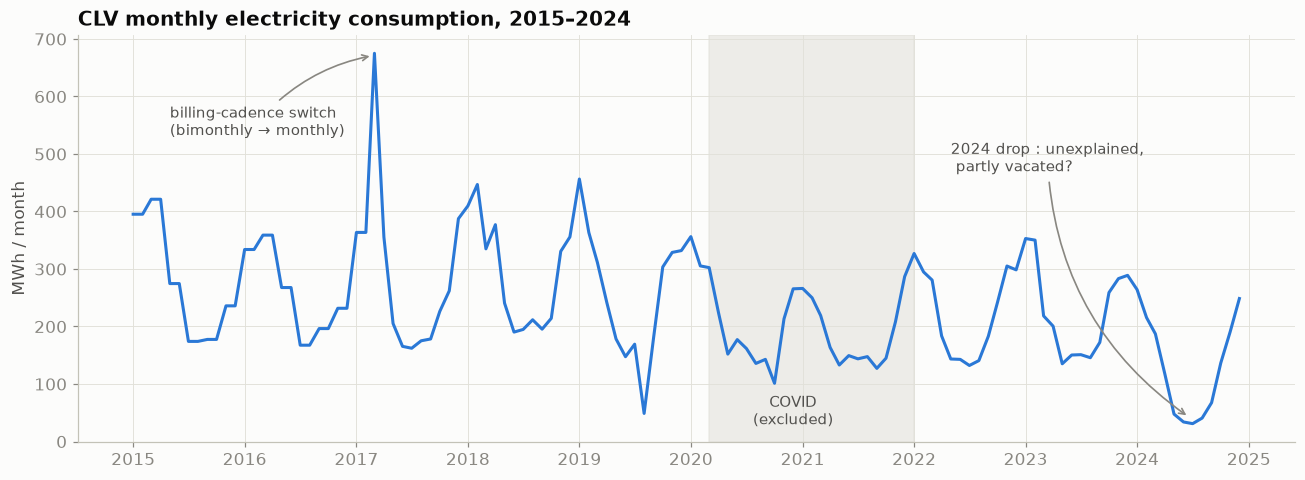

In [15]:
elec = pd.read_csv(DATA / "Electricity Consumption Monthly.csv")
raw = elec[elec["Building Code"] == "CLV"].copy()
raw["month"] = pd.to_datetime(raw["Start Date"])
s = raw.set_index("month")["Consumption"].sort_index()  # NaN on the skipped months

# Bimonthly readings (pre-2017) show up as a value followed by a blank month, with
# the reading holding both months' consumption. Spread each reading evenly over
# the months up to the next actual reading, giving a true per-month rate.
vals = s.dropna()
clv = pd.Series(0.0, index=s.index)
boundaries = list(vals.index) + [s.index[-1] + pd.offsets.MonthBegin(1)]
for m, nxt, v in zip(boundaries[:-1], boundaries[1:], vals):
    span = s.index[(s.index >= m) & (s.index < nxt)]
    clv[span] = v / len(span)

baseline = clv["2022":"2023"]
monthly_demand = baseline.groupby(baseline.index.month).mean()  # kWh per calendar month
annual_demand = monthly_demand.sum()
demand_2024 = clv["2024"].sum()
print(f"CLV baseline demand (2022–23): {annual_demand/1e6:.2f} GWh/yr "
      f"(seasonal range {monthly_demand.min()/1e3:.0f}–{monthly_demand.max()/1e3:.0f} MWh/month)")
print(f"CLV 2024 demand (anomalous):   {demand_2024/1e6:.2f} GWh/yr")

fig, ax = plt.subplots()
ax.plot(clv.index, clv / 1e3, color=BLUE, lw=2)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31"), color=GRID, alpha=0.55, zorder=0)
ax.annotate("COVID\n(excluded)", xy=(pd.Timestamp("2020-12-01"), 30), ha="center",
            fontsize=9.5, color=INK2)
ax.annotate("billing-cadence switch\n(bimonthly → monthly)", xy=(pd.Timestamp("2017-03-05"), 672),
            xytext=(pd.Timestamp("2015-05-01"), 585), fontsize=9.5, color=INK2, ha="left", va="top",
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.1,
                            connectionstyle="arc3,rad=-0.18", shrinkB=4))
ax.annotate("2024 drop : unexplained,\n partly vacated?", xy=(pd.Timestamp("2024-07-01"), 38),
            xytext=(pd.Timestamp("2022-05-01"), 470), fontsize=9.5, color=INK2, ha="left",
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.1,
                            connectionstyle="arc3,rad=0.25", shrinkB=5))
ax.set_title("CLV monthly electricity consumption, 2015–2024", loc="left", fontweight="bold")
ax.set_ylabel("MWh / month")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 3. PV yield per kW — pvlib simulation with local weather

The station measures only global horizontal irradiance (GHI), so we estimate the direct/diffuse split
with the **Erbs** model, transpose to the 35°-tilt plane of array, and run the **PVWatts** chain with a
cell-temperature model (open-rack glass/glass). Losses: PVWatts system losses (~14%) plus the monthly
**snow-loss factors from the SAM guide** (30% Jan/Feb … 25% Dec).

In [4]:
solpos = pvlib.solarposition.get_solarposition(w.index, LAT, LON)
erbs = pvlib.irradiance.erbs(w["ghi"], solpos["zenith"], w.index)

poa = pvlib.irradiance.get_total_irradiance(
    TILT, AZIMUTH, solpos["apparent_zenith"], solpos["azimuth"],
    dni=erbs["dni"], ghi=w["ghi"], dhi=erbs["dhi"],
)["poa_global"]

params = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"]["open_rack_glass_glass"]
t_cell = pvlib.temperature.sapm_cell(poa, w["temp_air"], w["wind_speed"], **params)

# DC output of a 1 kW array, then PVWatts system losses (soiling, wiring, inverter, ...)
pdc = pvlib.pvsystem.pvwatts_dc(poa, t_cell, pdc0=1.0, gamma_pdc=-0.004)
loss_frac = pvlib.pvsystem.pvwatts_losses() / 100
pac = pdc * (1 - loss_frac)

SNOW_LOSS = {1: .30, 2: .30, 3: .15, 4: .05, 5: .05, 6: .05, 7: .05,
             8: .05, 9: .05, 10: .05, 11: .10, 12: .25}   # NREL_SAM.md step 6

good = pac[pac.index.year.isin(GOOD_YEARS)]
monthly_per_kw = good.groupby([good.index.year, good.index.month]).sum()
monthly_per_kw = monthly_per_kw.groupby(level=1).mean()            # kWh/kW per calendar month
monthly_per_kw *= pd.Series(SNOW_LOSS).rsub(1)                     # apply snow losses
yield_per_kw = monthly_per_kw.sum()
print(f"specific yield ({', '.join(map(str, GOOD_YEARS))} weather, after snow losses): "
      f"{yield_per_kw:.0f} kWh/kW/yr")

specific yield (2016, 2020, 2021, 2023, 2024 weather, after snow losses): 1035 kWh/kW/yr


## 4. System size from measured roofs (Google Solar API)

269 CLV buildings (individual townhouse units), measured from Google's HIGH-quality aerial model via a
12 m probe sweep of the village polygon. `maxArrayPanelsCount` already excludes roof planes that are too
steep, north-facing, or shaded. Cross-check: an independent QGIS tracing of the 50 block footprints
gives 19,883 m² — within ~6% of Google's 18,617 m² (blocks include eaves overhang).

In [5]:
roofs = pd.DataFrame(json.loads(API_SUMMARY.read_text()))
PANEL_W = 400  # Google default panel assumption, W DC
system_kw = roofs["panels"].sum() * PANEL_W / 1000

print(f"buildings: {len(roofs)}   roof area: {roofs['roof_m2'].sum():,.0f} m²")
print(f"max panels: {roofs['panels'].sum():,}   →  system size: {system_kw:,.0f} kW DC")
print(f"Google's own yield estimate: {roofs['kwh_dc'].sum()/1e3:,.0f} MWh DC/yr")

# Cross-check: two independent models of specific yield
google_specific = roofs["kwh_dc"].sum() / system_kw
ours_dc = (pdc[pdc.index.year.isin(GOOD_YEARS)]
           .groupby([pdc[pdc.index.year.isin(GOOD_YEARS)].index.year,
                     pdc[pdc.index.year.isin(GOOD_YEARS)].index.month]).sum()
           .groupby(level=1).mean().sum())
print(f"\nspecific DC yield — Google (aerial model): {google_specific:.0f} kWh/kW/yr"
      f"\nspecific DC yield — pvlib (local weather): {ours_dc:.0f} kWh/kW/yr"
      f"\nagreement: {100 * min(google_specific, ours_dc) / max(google_specific, ours_dc):.0f}%")

buildings: 269   roof area: 18,617 m²
max panels: 4,897   →  system size: 1,959 kW DC
Google's own yield estimate: 2,484 MWh DC/yr

specific DC yield — Google (aerial model): 1268 kWh/kW/yr
specific DC yield — pvlib (local weather): 1334 kWh/kW/yr
agreement: 95%


## 5. Generation vs demand — how much of CLV's load does the roof cover?

Monthly resolution (the consumption data is monthly). Note the *annual* offset is what feeds the
impact slide; hourly self-consumption analysis would need interval meter data.

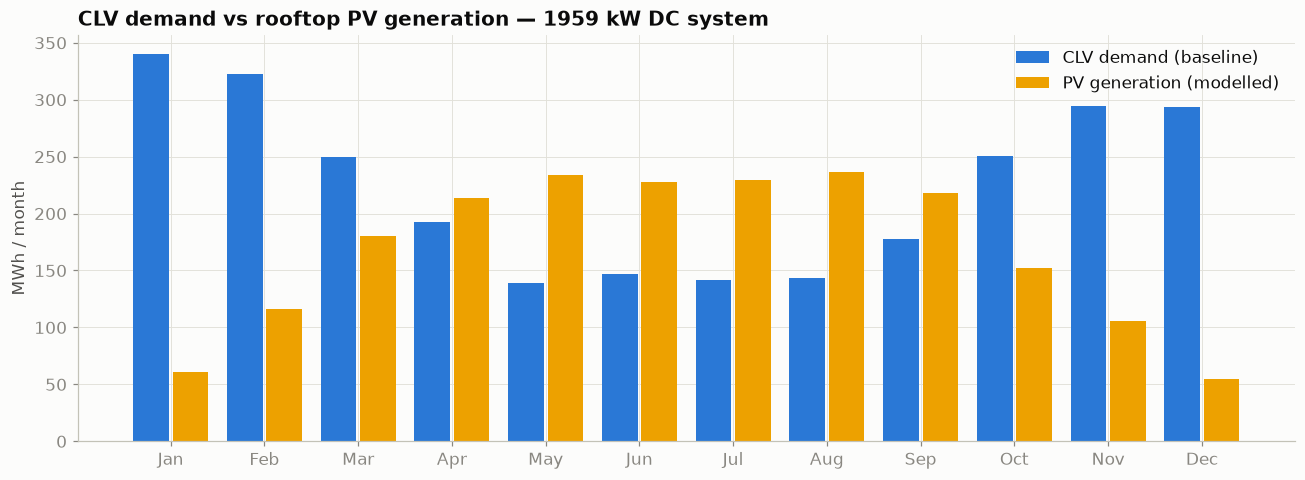

annual generation: 2.03 GWh
→ covers 75% of the 2022–23 baseline demand (2.69 GWh)
→ covers 128% of demand at the reduced 2024 level (1.58 GWh)
monthly resolution: 162% of July demand, 18% of January demand


In [6]:
gen = monthly_per_kw * system_kw  # kWh per calendar month, snow-adjusted
months = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()
x = np.arange(12)

fig, ax = plt.subplots()
ax.bar(x - 0.21, monthly_demand.values / 1e3, width=0.38, color=BLUE, label="CLV demand (baseline)")
ax.bar(x + 0.21, gen.values / 1e3, width=0.38, color=YELLOW, label="PV generation (modelled)")
ax.set_xticks(x, months)
ax.set_title(f"CLV demand vs rooftop PV generation — {system_kw:.0f} kW DC system",
             loc="left", fontweight="bold")
ax.set_ylabel("MWh / month")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

annual_gen = gen.sum()
print(f"annual generation: {annual_gen/1e6:.2f} GWh")
print(f"→ covers {annual_gen/annual_demand:.0%} of the 2022–23 baseline demand "
      f"({annual_demand/1e6:.2f} GWh)")
print(f"→ covers {annual_gen/demand_2024:.0%} of demand at the reduced 2024 level "
      f"({demand_2024/1e6:.2f} GWh)")
print(f"monthly resolution: {gen[7]/monthly_demand[7]:.0%} of July demand, "
      f"{gen[1]/monthly_demand[1]:.0%} of January demand")

## 6. Emissions impact

Ontario's grid is already low-carbon, so the *average* emission factor is small; the *marginal*
generation displaced by daytime solar is usually gas-fired and carries a much higher factor.
Both are reported — quote the marginal figure when arguing displaced emissions, and say so.

In [7]:
EF_AVG = 81 / 1e6        # t CO2e per kWh — Ontario average intensity, rising w/ nuclear refurbs (TAF/IESO 2026)
EF_MARGINAL = 320 / 1e6  # t CO2e per kWh — marginal displacement incl. import blend (Power Advisory)

print(f"CO2e avoided @ average grid intensity : {annual_gen * EF_AVG:6.0f} t/yr")
print(f"CO2e avoided @ marginal (gas) intensity: {annual_gen * EF_MARGINAL:6.0f} t/yr")

CO2e avoided @ average grid intensity :    164 t/yr
CO2e avoided @ marginal (gas) intensity:    649 t/yr


## 7. Economics — researched parameters, scenario grid

Sourced inputs (July 2026):
- **Capex**: Canadian commercial rooftop runs C$1.90–2.80/W; large systems (500 kW–1 MW+) reach
  C$1.30–1.50/W on single clean roofs. CLV is ~2 MW *distributed over 269 townhouse roofs*, so
  small-commercial pricing applies: scenarios at C$1.70 / 2.10 / 2.60 per W (greenbuildingcanada.ca,
  magsolar.ca 2026 guides).
- **O&M**: the physical portfolio is **~50 buildings** (continuous block roofs of ~39 kW each) —
  the 269 figure is dwelling-unit accounting, not separate systems. One system per block is the
  natural design. Three independent estimates for a block-aggregated 50-site portfolio: deep-research
  C$15–22, Canadian single-site commercial C$20–30, distributed-premium view C$25–35.
  **C$22/kW/yr used** (state the C$15–30 spread when presenting).
- **Net metering**: O. Reg. 541/05 caps net metering at **500 kW per meter** (12-month credit
  expiry per s.8(8)). Earlier drafts said the cap was removed — that traced to installer SEO pages
  with a bad citation; the 2018 liberalizing amendment (O. Reg. 273/18) was *revoked* before taking
  effect. Consequence: only ~500 kW can earn net-metering credits on CLV's meter; capacity beyond
  that operates as load displacement (self-consumption, no export credits) or under a third-party
  PPA structure. Waterloo's LDC (Enova Power) also requires a generation meter above 50 kW.
- **Incentives**: UW is tax-exempt and cannot claim the 30% federal Clean Technology ITC directly.
  Two real paths: the refundable **15% Clean Electricity ITC** (broader public-sector claimant base),
  or third-party ownership/PPA where a taxable developer claims the 30% Clean Tech ITC and passes
  savings through. Both federal ITCs carry labour requirements (prevailing wage/apprenticeship);
  non-compliance cuts the rate by 10 points. Grid below shows ITC 0% and 15%.

The SAM model (sized to this system, with these inputs) remains the authoritative cash-flow analysis.

In [8]:
RATE = 0.145              # C$/kWh — energy charge from the challenge rate structure
OM_PER_KW = 22.0          # C$/kW/yr — block-aggregated portfolio; deep-research est. 15-22, commercial 20-30
LIFETIME = 25             # years
DEGRADATION = 0.005       # 0.5 %/yr output loss

om = system_kw * OM_PER_KW
value_yr1 = annual_gen * RATE
yrs = np.arange(1, LIFETIME + 1)
lifetime_gen = (annual_gen * (1 - DEGRADATION) ** (yrs - 1)).sum()

print(f"year-1 energy value: C$ {value_yr1/1e3:.0f} k/yr   O&M: C$ {om/1e3:.0f} k/yr\n")
print(f"{'capex C$/W':>10} {'ITC':>5} {'net capex':>10} {'payback':>8} {'LCOE':>7}")
for cpw in (2.10, 2.35, 2.60):
    for itc in (0.0, 0.15):
        capex = system_kw * 1000 * cpw * (1 - itc)
        payback = capex / (value_yr1 - om)
        lcoe = (capex + om * LIFETIME) / lifetime_gen
        print(f"{cpw:>10.2f} {itc:>5.0%} {capex/1e6:>9.2f}M {payback:>7.1f}y {lcoe:>6.3f}")
print(f"\ngrid rate for comparison: C${RATE}/kWh")
print("ITC 15% = refundable Clean Electricity ITC (if UW qualifies via public-sector rules);")
print("a 30% Clean Tech ITC is reachable only via third-party/PPA ownership structures.")

year-1 energy value: C$ 294 k/yr   O&M: C$ 43 k/yr

capex C$/W   ITC  net capex  payback    LCOE
      2.10    0%      4.11M    16.4y  0.109
      2.10   15%      3.50M    13.9y  0.096
      2.35    0%      4.60M    18.3y  0.119
      2.35   15%      3.91M    15.6y  0.104
      2.60    0%      5.09M    20.3y  0.129
      2.60   15%      4.33M    17.2y  0.113

grid rate for comparison: C$0.145/kWh
ITC 15% = refundable Clean Electricity ITC (if UW qualifies via public-sector rules);
a 30% Clean Tech ITC is reachable only via third-party/PPA ownership structures.


## 8. Site selection — CLV vs every other building in the dataset

Same pipeline applied campus-wide (Google Solar API, 2026-07-04; the multi-building complexes CLV
and UWP measured by sweeps over hand-verified boundary polygons, single buildings by direct lookup;
identical 0.82 DC→AC+snow derate). GC, BAU (near-zero meters) and CSB (campus-level feed meter, not
a building load) are excluded from the coverage panel. **The two residence complexes hold more
usable roof than every other measured building combined.** CLV has the largest verified roof
inventory and the highest self-coverage; UWP packs slightly more capacity on its flat tower roofs
and is the natural Phase-2 expansion (~2.3 MW, ~43% self-coverage).

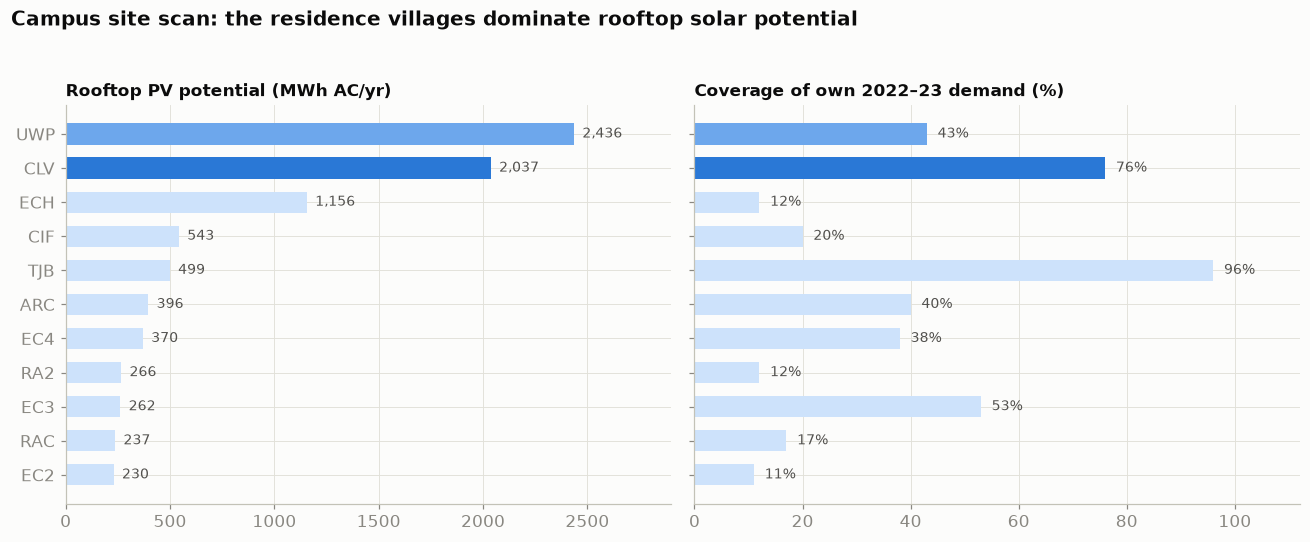

Residences (UWP+CLV): 4,473 MWh/yr potential — vs 3,959 MWh/yr for all other measured buildings combined


In [9]:
# (site, generation MWh AC/yr, coverage of 2022-23 baseline %) — campus scan 2026-07-04
sites = [("UWP", 2436, 43), ("CLV", 2037, 76), ("ECH", 1156, 12), ("CIF", 543, 20),
         ("TJB", 499, 96), ("ARC", 396, 40), ("EC4", 370, 38), ("RA2", 266, 12),
         ("EC3", 262, 53), ("RAC", 237, 17), ("EC2", 230, 11)]

names = [s[0] for s in sites][::-1]
gen = [s[1] for s in sites][::-1]
cov = [s[2] for s in sites][::-1]
emph = {"CLV": BLUE, "UWP": "#6da7ec"}
colors = [emph.get(n, "#cde2fb") for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
y = np.arange(len(names))
ax1.barh(y, gen, color=colors, height=0.62)
ax1.set_yticks(y, names)
ax1.set_title("Rooftop PV potential (MWh AC/yr)", loc="left", fontweight="bold", fontsize=11)
for i, v in enumerate(gen):
    ax1.text(v + 40, i, f"{v:,}", va="center", fontsize=9, color=INK2)
ax1.set_xlim(0, 2900)

ax2.barh(y, cov, color=colors, height=0.62)
ax2.set_title("Coverage of own 2022–23 demand (%)", loc="left", fontweight="bold", fontsize=11)
for i, v in enumerate(cov):
    ax2.text(v + 2, i, f"{v}%", va="center", fontsize=9, color=INK2)
ax2.set_xlim(0, 112)

fig.suptitle("Campus site scan: the residence villages dominate rooftop solar potential",
             x=0.01, ha="left", fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print("Residences (UWP+CLV): {:,} MWh/yr potential — vs {:,} MWh/yr for all other measured buildings combined".format(
    gen[names.index("UWP")] + gen[names.index("CLV")],
    sum(v for n, v in zip(names, gen) if n not in ("UWP", "CLV"))))

## Conclusions

*(re-run all cells to refresh; numbers below are produced by the cells above)*

- **Technical**: 269 CLV buildings offer ~18,600 m² of viable roof (validated within ~6% by an
  independent QGIS block tracing); a ~1.96 MW DC array fits on the planes Google's model rates as
  suitable. Two independent yield models (pvlib + on-campus weather vs Google's aerial model) agree
  within ~5%, so the generation estimate is robust.
- **Impact**: full build-out covers ~75% of CLV's fully-occupied annual demand (2022–23 baseline) —
  but overshoots summer months (Jul generation ≈ 160% of Jul load), so exports/net-metering terms
  drive the economics at this size. A demand-matched build-out of roughly 1.2 MW avoids monthly
  surpluses; present full and demand-matched as the two scenarios.
- **Economic**: with deep-research-verified 2026 costs (capex C$2.10–2.60/W central 2.35;
  O&M C$22/kW/yr block-aggregated) simple payback spans ~14–20 years and undiscounted LCOE
  C$0.10–0.14/kWh vs the C$0.145 grid rate. **Net metering is capped at 500 kW per meter**, so the
  deployment story is staged: a 500 kW net-metered phase 1, with expansion beyond that as load
  displacement or third-party PPA (which also unlocks the 30% Clean Tech ITC).
  UW cannot claim the 30% Clean Tech ITC directly (tax-exempt) — the 15% refundable Clean
  Electricity ITC or a third-party PPA are the real incentive paths. SAM adds financing, demand
  charges, net-metering rollover, and inflation for the final numbers.

**Unresolved**: the cause of CLV's 2024 consumption drop could not be confirmed (organizers asked,
public records checked). The analysis is robust to it — coverage is reported against both the
fully-occupied baseline and the reduced 2024 level. If part of the village is being wound down,
PV planning should target the remaining blocks or be designed into the redevelopment.

**Limitations** — monthly (not hourly) load matching; snow losses taken from the SAM guide rather
than measured; capex and emission factors are cited assumptions; structural capacity of CLV roofs
requires on-site assessment.